<div align="center">
 
### Lab 02 | The Physics of EEG

### Cortical Dipoles • Neuronal Synchrony • Signal Formation

---

**Programming Environment:** Python  
**Libraries:** NumPy • Matplotlib  
**Methodology:** Computational Simulation  

</div>

---

#### Learning Outcomes

By completing this lab, you will be able to:

---
### 
1.	Simulate neuronal synchrony and quantify how it affects EEG amplitude
2.	Model a simplified dipole potential and quantify the effect of depth (distance)
3.	Model dipole orientation effects and programmatically detect key angles
4.	Simulate multi-dipole interference and relate it to EEG spatial resolution
5.	Produce plots + numeric metrics as evidence


In [11]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def rms(x):
    return np.sqrt(np.mean(x**2))

def peak_abs(x):
    return np.max(np.abs(x))

### Part A — Neuronal Synchrony: Simulation + Quantification

#### Step 1 – Generate synchronous vs asynchronous population signals (Run as-is)

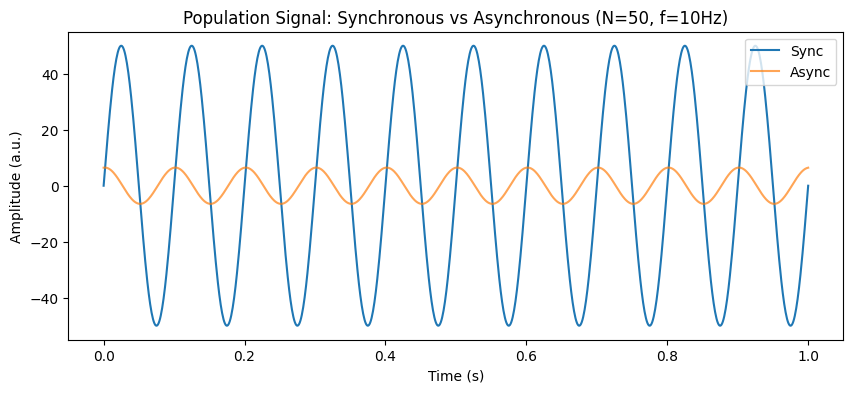

In [14]:
t = np.linspace(0, 1, 1000)   # 1 second
f = 10                        # 10 Hz rhythm
N = 50                        # number of neurons

# Synchronous neurons: same phase
sync_signal = np.sum([np.sin(2*np.pi*f*t) for _ in range(N)], axis=0)

# Asynchronous neurons: random phase
async_signal = np.sum([np.sin(2*np.pi*f*t + np.random.rand()*2*np.pi) for _ in range(N)], axis=0)

plt.figure(figsize=(10,4))
plt.plot(t, sync_signal, label="Sync")
plt.plot(t, async_signal, label="Async", alpha=0.7)
plt.title("Population Signal: Synchronous vs Asynchronous (N=50, f=10Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.legend()
plt.show()


#### Step 2 – Compute amplitude metrics

In [17]:
# TODO 1: Compute RMS and Peak amplitude for sync_signal
sync_rms = rms(sync_signal)
sync_peak = peak_abs(sync_signal)

# TODO 2: Compute RMS and Peak amplitude for async_signal
async_rms = rms(sync_signal)
async_peak = peak_abs(sync_signal)

print("Sync RMS:", sync_rms, "Sync Peak:", sync_peak)
print("Async RMS:", async_rms, "Async Peak:", async_peak)


Sync RMS: 35.33765696816924 Sync Peak: 49.9999381914299
Async RMS: 35.33765696816924 Async Peak: 49.9999381914299


#### Step 3 – Experiment: RMS vs Neuron Count

Student Task: Create a loop for different N values and plot RMS scaling.

Output expectation:
Sync RMS should increase much faster than Async RMS
Shows EEG measures synchrony

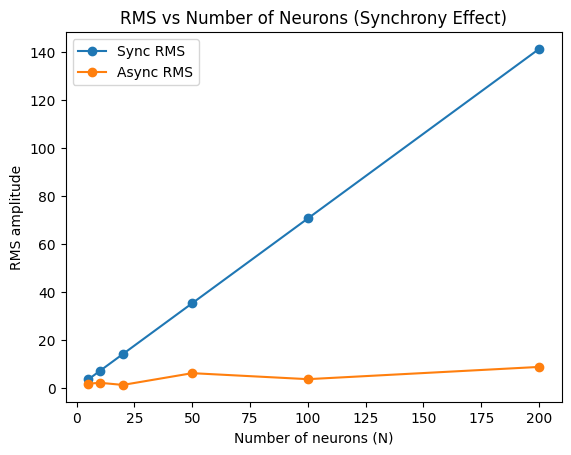

In [18]:
Ns = [5, 10, 20, 50, 100, 200]
sync_rms_list = []
async_rms_list = []

for N in Ns:
    sync = np.sum([np.sin(2*np.pi*f*t) for _ in range(N)], axis=0)
    async_ = np.sum([np.sin(2*np.pi*f*t + np.random.rand()*2*np.pi) for _ in range(N)], axis=0)

    sync_rms_list.append(rms(sync))
    async_rms_list.append(rms(async_))
    

plt.figure()
plt.plot(Ns, sync_rms_list, marker='o', label="Sync RMS")
plt.plot(Ns, async_rms_list, marker='o', label="Async RMS")
plt.title("RMS vs Number of Neurons (Synchrony Effect)")
plt.xlabel("Number of neurons (N)")
plt.ylabel("RMS amplitude")
plt.legend()
plt.show()

### Part B — Dipole Depth Effect: Voltage vs Distance

#### Step 4 – Simulate dipole potential vs distance (Run as-is)
We use a simplified relationship:
![alt text](image.png)

Where:

V = electric potential
p = dipole strength
r = distance from dipole
This is a simplified forward model.

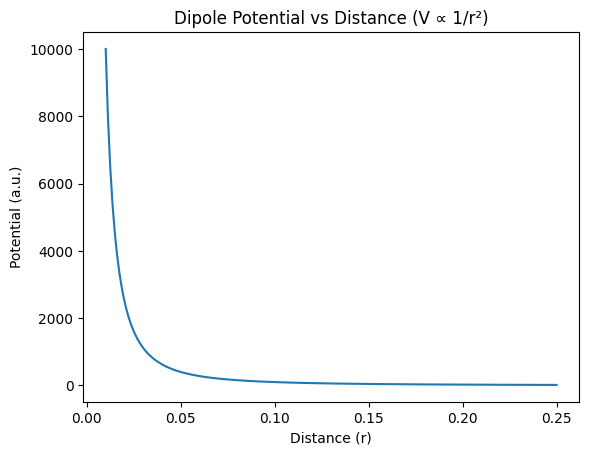

In [20]:
r = np.linspace(0.01, 0.25, 200)  # distance
p = 1.0                           # dipole strength

V = p / (r**2)

plt.figure()
plt.plot(r, V)
plt.title("Dipole Potential vs Distance (V ∝ 1/r²)")
plt.xlabel("Distance (r)")
plt.ylabel("Potential (a.u.)")
plt.show()


#### Step 5 – Depth experiment: compare multiple depths (Complete TODO)

Student Task: For each depth, compute peak potential and plot.

Output expectation:Peak potential drops rapidly as depth increases

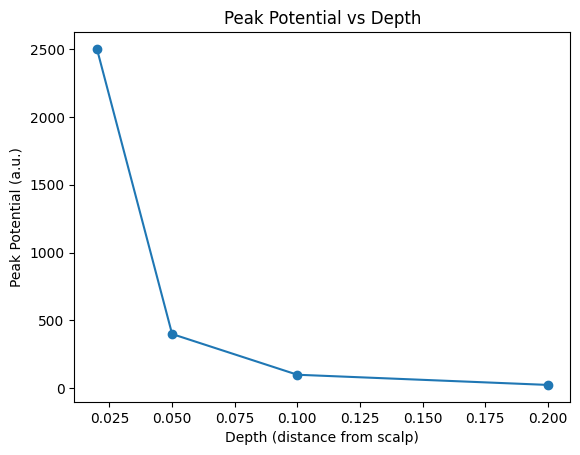

In [21]:
depths = [0.02, 0.05, 0.10, 0.20]  # deeper = larger r
peaks = []

for d in depths:
    V_d = p / (d**2)
    peaks.append(V_d)

plt.figure()
plt.plot(depths, peaks, marker='o')
plt.title("Peak Potential vs Depth")
plt.xlabel("Depth (distance from scalp)")
plt.ylabel("Peak Potential (a.u.)")
plt.show()


### Part C — Dipole Orientation Effect (Visibility in EEG)

We now extend the dipole equation: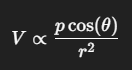

	p= dipole strength
	r= distance
	θ= orientation angle between dipole axis and electrode


#### Step 6 – Plot voltage vs orientation (Run as-is)

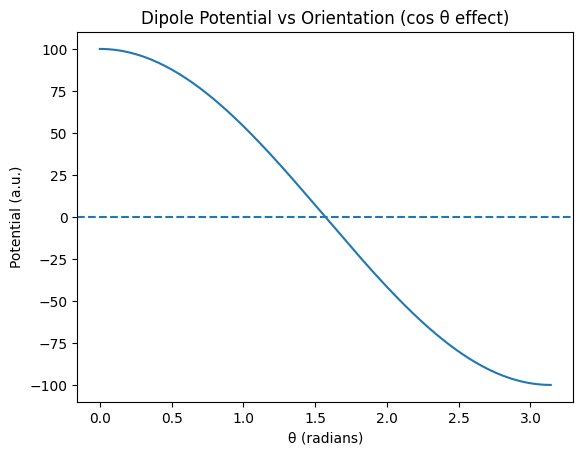

In [22]:
theta = np.linspace(0, np.pi, 200)
r_fixed = 0.1
p = 1.0

V_theta = (p * np.cos(theta)) / (r_fixed**2)

plt.figure()
plt.plot(theta, V_theta)
plt.axhline(0, linestyle='--')
plt.title("Dipole Potential vs Orientation (cos θ effect)")
plt.xlabel("θ (radians)")
plt.ylabel("Potential (a.u.)")
plt.show()


#### Step 7 – Detect key angles programmatically (Complete TODO)

Student Task: Find angle where potential is ~0 and where it is maximum.
Expected:
    
    Zero near π/2
    Max near 0

In [23]:
# TODO 5: angle where V_theta is closest to 0
theta_zero = theta[np.argmin(np.abs(V_theta))]

# TODO 6: angle where V_theta is maximum
theta_max = theta[np.argmax(V_theta)]


print("Zero-potential angle (approx):", theta_zero)
print("Max-potential angle:", theta_max)


Zero-potential angle (approx): 1.5629028779165304
Max-potential angle: 0.0


### Part D — Two Dipoles Interference (Spatial Resolution)

#### Step 8 – Create 2D grid and simulate fields (Run as-is)

In [24]:
x = np.linspace(-1, 1, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)

eps = 0.02  # avoid division by zero                         

#### tep 9 – Two dipoles at different positions (Complete TODO)

Student Task: Implement dipole1, dipole2 and combine.

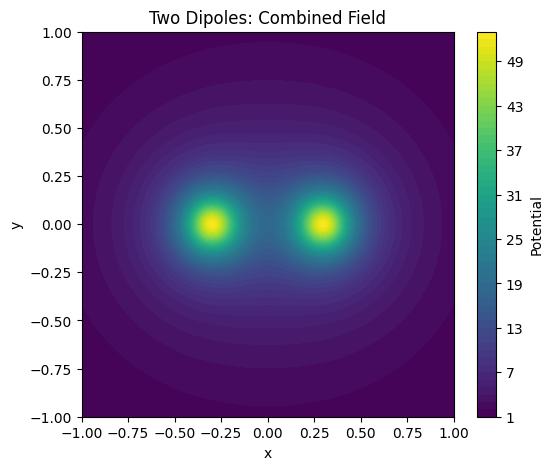

In [26]:
# Dipole positions
x1, y1 = -0.3, 0
x2, y2 =  0.3, 0

# TODO 7: compute distance R1 and R2
R1 = np.sqrt((X - x1)**2 + (Y - y1)**2)
R2 = np.sqrt((X - x2)**2 + (Y - y2)**2)

# TODO 8: compute potentials V1 and V2 using 1/(R^2 + eps)
V1 = 1 / (R1**2 + eps)
V2 = 1 / (R2**2 + eps)

V_total = V1+V2

plt.figure(figsize=(6,5))
plt.contourf(X, Y, V_total, levels=60)
plt.colorbar(label="Potential")
plt.title("Two Dipoles: Combined Field")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


#### Step 10 – Move dipoles closer and observe merging (Complete TODO)

Student Task: Implement dipole1, dipole2 and combine.

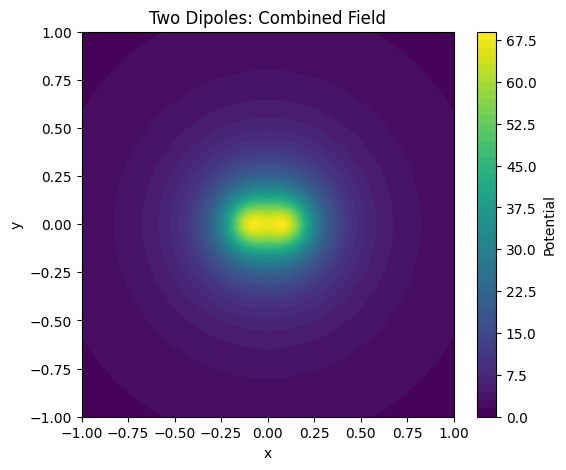

In [27]:
# Dipole positions
x1, y1 = -0.1, 0
x2, y2 =  0.1, 0

# TODO 7: compute distance R1 and R2
R1 = np.sqrt((X - x1)**2 + (Y - y1)**2)
R2 = np.sqrt((X - x2)**2 + (Y - y2)**2)

# TODO 8: compute potentials V1 and V2 using 1/(R^2 + eps)
V1 = 1 / (R1**2 + eps)
V2 = 1 / (R2**2 + eps)

V_total = V1 + V2

plt.figure(figsize=(6,5))
plt.contourf(X, Y, V_total, levels=60)
plt.colorbar(label="Potential")
plt.title("Two Dipoles: Combined Field")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


#### Step 10 – Move dipoles closer and observe merging (Complete TODO)

Student Task: Repeat the simulation for closer dipoles.

Change:

x1, x2 = -0.1, 0.1

Compare:

    Field overlap increases

    Harder to distinguish two sources

    Demonstrates poor spatial resolution

##### Short Computational Conclusions

Write 1–2 lines for each:

How does RMS scale with N for sync vs async?
Synchronous RMS scales approximately linearly with N, while asynchronous RMS scales approximately with √N. This demonstrates that EEG amplitude depends strongly on neuronal synchrony rather than just neuron count.


What happens to potential when depth increases?
Potential decreases rapidly with depth following an inverse-square relationship (1/r²). Deeper cortical sources produce much weaker EEG signals.

Which orientation gives near-zero EEG voltage?
Voltage approaches zero when θ ≈ π/2 (dipole perpendicular to electrode axis). Maximum voltage occurs at θ ≈ 0.

What happens when two dipoles get closer?
As dipoles move closer, their electric fields overlap and merge, making them difficult to distinguish. This demonstrates the limited spatial resolution of EEG.